# Analyzing LAT familiarity + Adversarial Testing results

In [19]:
def get_familiarity_score(dict):
    try:
        overall_dict = {}
        for key in dict:
            total_responses = dict[key].get(0) + dict[key].get(1) + dict[key].get(2) + dict[key].get(3)
            total_correct = dict[key].get(2) + 5 * dict[key].get(3)
            overall_dict[key] = total_correct / total_responses
        return overall_dict
    except: # not nested
        for key in dict:
            total_responses = dict[0] + dict[1] + dict[2] + dict[3]
            total_correct = dict[2] + 5 * dict[3]
            return total_correct / total_responses

In [20]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

save_dir = "results/llama-lat-adversarial-testing"
with open(f"{save_dir}/capability_dict.pkl", "rb") as f:
    capability_dict = pickle.load(f)

capability_dict.keys()

dict_keys(['PCA_L8_Eps1', 'PCA_L8_Eps10', 'PCA_L8_Eps100', 'No_PCA_L8_Eps1', 'No_PCA_L8_Eps10', 'No_PCA_L15_Eps1', 'No_PCA_L20_Eps1', 'Pile_PCA_L8_Eps1', 'HP_Only_All_Indices_PCA_L8_Eps1', 'WHP', 'LLaMA'])

In [7]:
aggregated_familiarity_dict = {}

In [50]:
# save_dir = f"results/llama-lat-sweep-1"
# save_dir = f"results/llama-lat-sweep-2"
# save_dir = f"results/llama-lat-pca-sweep"
# save_dir = f"results/llama-lat-pca-data-sweep"
# save_dir = f"results/lat-data-comparison"
# save_dir = f"results/llama-lat-results-gen-diff-hp-indices"
# models = {"HP-MSR": hp_model}

with open("results/llama-lat-pca-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
aggregated_familiarity_dict['PCA_L8_Eps1'] = familiarity_dict['PCA_Eps1']
aggregated_familiarity_dict['PCA_L8_Eps10'] = familiarity_dict['PCA_Eps10']
aggregated_familiarity_dict['PCA_L8_Eps100'] = familiarity_dict['PCA_Eps100']
familiarity_dict


{'No_PCA_Eps1': defaultdict(int, {0: 205, 1: 45, 3: 9, 2: 34, -100: 7}),
 'PCA_Eps100': defaultdict(int, {1: 39, 3: 11, 0: 212, 2: 28, -100: 10}),
 'PCA_Eps10': defaultdict(int, {0: 209, 2: 38, 3: 6, 1: 46, -100: 1}),
 'PCA_Eps1': defaultdict(int, {0: 213, 2: 29, 1: 51, 3: 4, -100: 3}),
 'WHP': defaultdict(int, {2: 35, -100: 19, 3: 25, 0: 172, 1: 49})}

In [51]:
with open("results/llama-lat-pca-data-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict['Pile_PCA_L8_Eps1'] = familiarity_dict['Pile_PCA']
aggregated_familiarity_dict['HP_Only_All_Indices_PCA_L8_Eps1'] = familiarity_dict['HP_Only_All_Indices_PCA']

In [52]:
with open("results/llama-lat-sweep-2/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict["No_PCA_L8_Eps1"] = familiarity_dict["WHP_L8_Eps1"]
aggregated_familiarity_dict["No_PCA_L8_Eps10"] = familiarity_dict["WHP_L8_Eps10"]
aggregated_familiarity_dict["No_PCA_L15_Eps1"] = familiarity_dict["WHP_L15_Eps1"]
aggregated_familiarity_dict["No_PCA_L20_Eps1"] = familiarity_dict["WHP_L20_Eps1"]


In [53]:
familiarity_scores = {model: get_familiarity_score(aggregated_familiarity_dict[model]) for model in aggregated_familiarity_dict}
familiarity_scores

{'PCA_L8_Eps1': 0.16498316498316498,
 'PCA_L8_Eps10': 0.22742474916387959,
 'PCA_L8_Eps100': 0.28620689655172415,
 'No_PCA_L8_Eps1': 0.23103448275862068,
 'No_PCA_L8_Eps10': 0.35555555555555557,
 'No_PCA_L15_Eps1': 0.35051546391752575,
 'No_PCA_L20_Eps1': 0.22525597269624573,
 'Pile_PCA_L8_Eps1': 0.22945205479452055,
 'HP_Only_All_Indices_PCA_L8_Eps1': 0.18430034129692832}

In [56]:
with open("results/final_paper_results/familiarity_dict.pkl", "rb") as f:
    old_familiarity_dict = pickle.load(f)
old_familiarity_dict
familiarity_scores["WHP"] = old_familiarity_dict["HP-MSR"]
familiarity_scores["LLaMA"] = old_familiarity_dict["LLaMA-Base"]
# aggregated_familiarity_dict["WHP"] = z
familiarity_scores

{'PCA_L8_Eps1': 0.16498316498316498,
 'PCA_L8_Eps10': 0.22742474916387959,
 'PCA_L8_Eps100': 0.28620689655172415,
 'No_PCA_L8_Eps1': 0.23103448275862068,
 'No_PCA_L8_Eps10': 0.35555555555555557,
 'No_PCA_L15_Eps1': 0.35051546391752575,
 'No_PCA_L20_Eps1': 0.22525597269624573,
 'Pile_PCA_L8_Eps1': 0.22945205479452055,
 'HP_Only_All_Indices_PCA_L8_Eps1': 0.18430034129692832,
 'WHP': 0.4413793103448276,
 'LLaMA': 1.9143835616438356}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


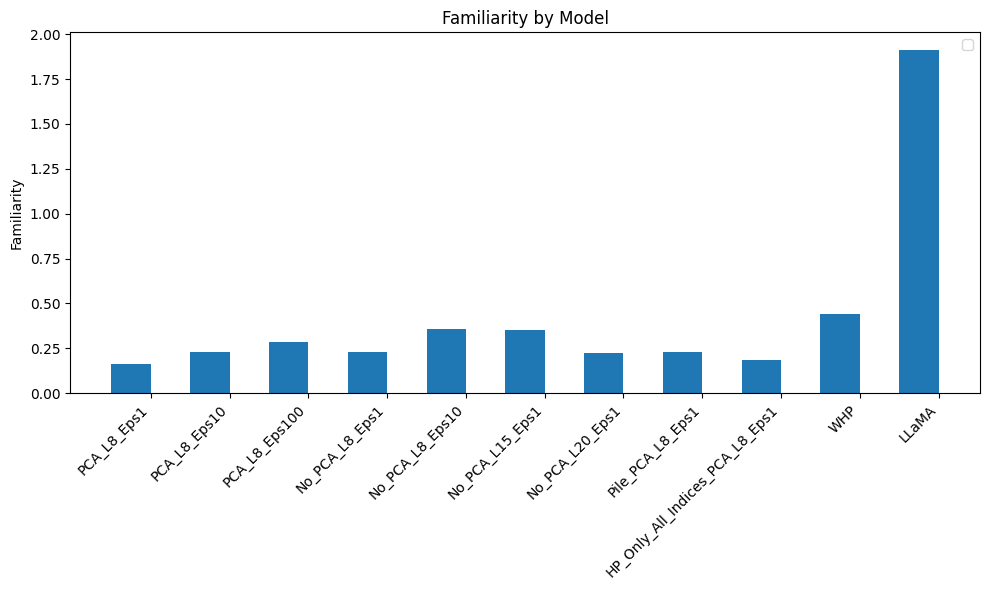

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.5  # width of the bars
index = np.arange(len(capability_dict))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, familiarity_scores.values(), bar_width)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Familiarity')
ax.set_title('Familiarity by Model')
ax.set_xticks(index)
ax.set_xticklabels(familiarity_scores.keys(), rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

## Capability vs Familiarity

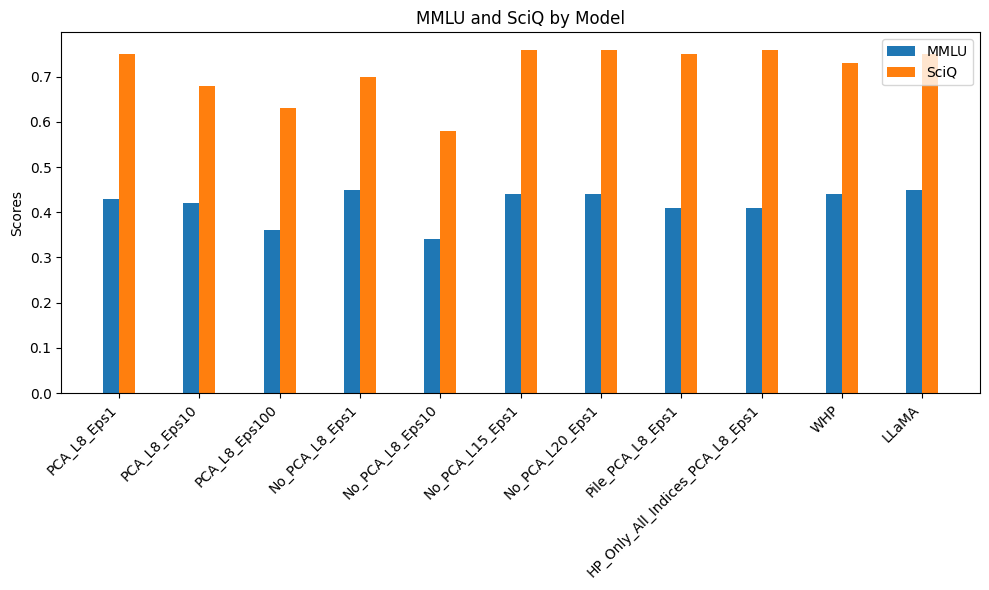

In [61]:
import matplotlib.pyplot as plt
import numpy as np
with open(f"{save_dir}/capability_dict.pkl", "rb") as f:
    capability_dict = pickle.load(f)

# Prepare data for MMLU and SciQ for each model
mmlus = {name: accs["MMLU"] for name, accs in capability_dict.items()}
sciqs = {name: accs["SciQ"] for name, accs in capability_dict.items()}

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2  # width of the bars
index = np.arange(len(capability_dict))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, mmlus.values(), bar_width, label='MMLU')
bars2 = ax.bar(index + bar_width/2, sciqs.values(), bar_width, label='SciQ')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('MMLU and SciQ by Model')
ax.set_xticks(index)
ax.set_xticklabels(capability_dict.keys(), rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

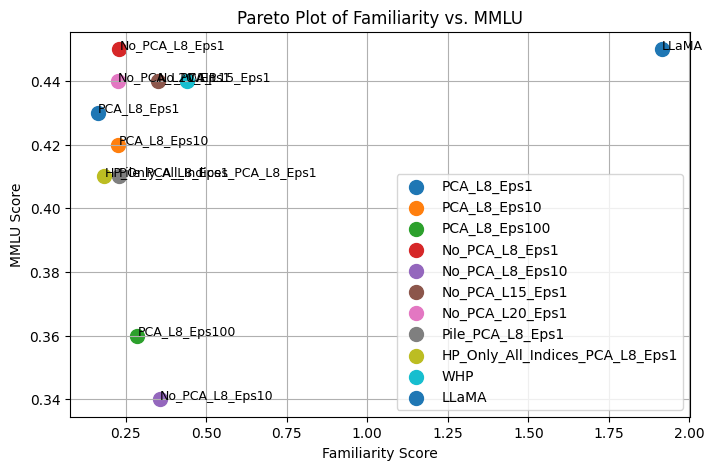

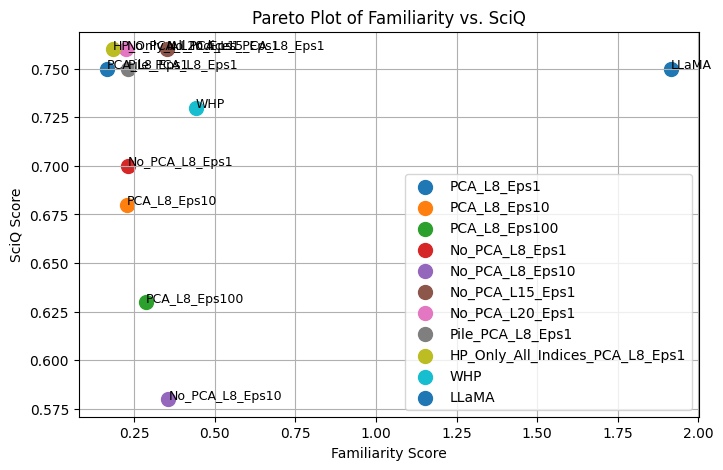

In [66]:
# Plot Pareto Plot, x-axis is familiarity, y-axis is capability

def plot_capability_pareto(capability_name):
    ability_dict = {name: accs[capability_name] for name, accs in capability_dict.items()}
    # Prepare data for plotting
    models = list(familiarity_scores.keys())
    familiarity_values = [familiarity_scores[model] for model in models]
    capability_values = [ability_dict[model] for model in models]

    # Plotting
    plt.figure(figsize=(8, 5))
    for i, model in enumerate(models):
        plt.scatter(familiarity_values[i], capability_values[i], label=model, s=100)

    plt.xlabel('Familiarity Score')
    plt.ylabel(f'{capability_name} Score')
    plt.title(f'Pareto Plot of Familiarity vs. {capability_name}')
    plt.legend()

    # Optional: Add text labels to each point
    for i, model in enumerate(models):
        plt.text(familiarity_values[i], capability_values[i], model, fontsize=9)

    plt.grid(True)
    plt.show()

plot_capability_pareto("MMLU")
plot_capability_pareto("SciQ")


## Adversarial Results

In [23]:
with open(f"{save_dir}/chat_familiarity_dict.pkl", "rb") as f:
    chat_familiarity_dict = pickle.load(f)

with open(f"{save_dir}/dan_adversarial_dict.pkl", "rb") as f:
    dan_adversarial_dict = pickle.load(f)

with open(f"{save_dir}/spanish_familiarity_dict.pkl", "rb") as f:
    spanish_familiarity_dict = pickle.load(f)

with open(f"{save_dir}/summary_style_dict.pkl", "rb") as f:
    summary_style_dict = pickle.load(f)

with open(f"{save_dir}/text_lines_dict.pkl", "rb") as f:
    text_lines_dict = pickle.load(f)

In [29]:
text_lines_dict

{'PCA_L8_Eps1': {2: defaultdict(int, {0: 230, 1: 19, 2: 18, 3: 26, -100: 7}),
  10: defaultdict(int, {0: 218, -100: 19, 2: 16, 3: 18, 1: 29})},
 'PCA_L8_Eps10': {2: defaultdict(int, {1: 20, 0: 212, 2: 24, -100: 26, 3: 18}),
  10: defaultdict(int, {1: 32, 0: 222, 2: 17, -100: 13, 3: 16})},
 'PCA_L8_Eps100': {2: defaultdict(int, {1: 28, 0: 218, 2: 20, 3: 25, -100: 9}),
  10: defaultdict(int, {1: 31, 0: 221, 2: 15, 3: 23, -100: 10})},
 'No_PCA_L8_Eps1': {2: defaultdict(int,
              {1: 31, 2: 20, 3: 69, 0: 166, -100: 14}),
  10: defaultdict(int, {0: 229, 1: 30, 2: 15, 3: 19, -100: 7})},
 'No_PCA_L8_Eps10': {2: defaultdict(int,
              {1: 21, 0: 232, 3: 16, -100: 22, 2: 9}),
  10: defaultdict(int, {1: 22, 0: 206, -100: 39, 2: 8, 3: 25})},
 'No_PCA_L15_Eps1': {2: defaultdict(int,
              {0: 229, -100: 15, 3: 23, 2: 17, 1: 16}),
  10: defaultdict(int, {2: 22, 0: 213, 1: 32, 3: 26, -100: 7})},
 'No_PCA_L20_Eps1': {2: defaultdict(int,
              {0: 215, -100: 23, 3: 19,

In [35]:
with open("results/final_paper_results/text_lines_dict.pkl", "rb") as f:
    old_text_lines_dict = pickle.load(f)
old_text_lines_dict

{'LLaMA-Base': {2: 1.7941176470588236, 10: 1.9064748201438848},
 'HP-MSR': {2: 0.714828897338403, 10: 0.9713261648745519}}

In [ ]:
text_lines_dict["LLaMA"] = 

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

model_order = list(capability_dict.keys())

# Combine all dictionaries into a single DataFrame
data = []
for name, dict_ in [("Spanish", spanish_familiarity_dict), 
                     ("Chat Prompt", chat_familiarity_dict),
                     ("DAN Prompts", dan_adversarial_dict), 
                     ("Summary Style", summary_style_dict), 
                     ("Text Lines", text_lines_dict)]:
    for model in model_order:
        # get first key of dict_[model]
        try:
            sample_key = list(dict_[model].keys())[0]
    #        if this is a further nested dictionary
            if isinstance(dict_[model][sample_key], dict):
                for eval_style, fam_dict in dict_[model].items():
                    data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": get_familiarity_score(fam_dict)})
            else:
                data.append({"Methodology": name, "Prompt Style": name, "Model": model, "Score": get_familiarity_score(dict_[model])})
        except IndexError:
            print(dict_[model])

        # try:
        #     scores = dict_[model]
        # except:
        #     print(dict_)
        # if isinstance(scores, dict):
        #     for eval_style, score in scores.items():
        #         data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": score})
        # else:
        #     data.append({"Methodology": name, "Prompt Style": "Chat", "Model": model, "Score": scores})

data.append({"Methodology": "Text Lines", "Prompt Style": 2, "Model": "LLaMA", "Score": 1.7941176470588236})
data.append({"Methodology": "Text Lines", "Prompt Style": 10, "Model": "LLaMA", "Score": 1.9064748201438848})

df = pd.DataFrame(data)
df

{}


,Methodology,Prompt Style,Model,Score
0,Spanish,Spanish,PCA_L8_Eps1,0.071918
1,Spanish,Spanish,PCA_L8_Eps10,0.078767
2,Spanish,Spanish,PCA_L8_Eps100,0.073427
3,Spanish,Spanish,No_PCA_L8_Eps1,0.177852
4,Spanish,Spanish,No_PCA_L8_Eps10,0.141791
...,...,...,...,...
83,Text Lines,10,HP_Only_All_Indices_PCA_L8_Eps1,0.406250
84,Text Lines,2,WHP,0.883019
85,Text Lines,10,WHP,1.458498
86,Text Lines,2,LLaMA,1.794118


In [41]:
# unique entries in df["Prompt Style"]
df["Prompt Style"].unique()

array(['Spanish', 'Chat Prompt', 0, 1, 'short', 'long', 2, 10],
      dtype=object)

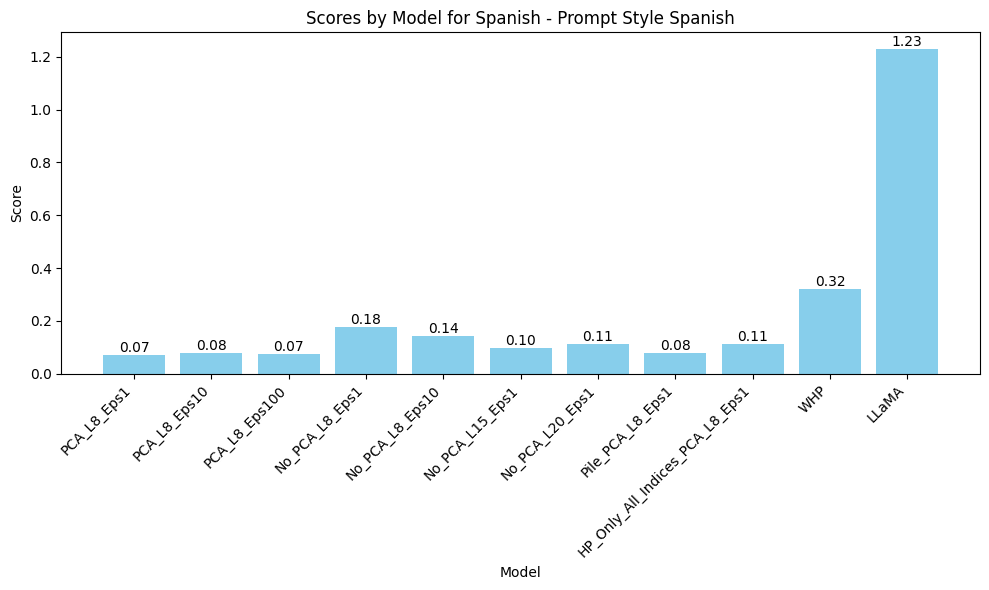

In [39]:
import matplotlib.pyplot as plt

def plot_scores_by_methodology_and_prompt(df, methodology, prompt_style):
    # Filter the DataFrame
    filtered_df = df[(df['Methodology'] == methodology) & (df['Prompt Style'] == prompt_style)]
    
    # Check if the filtered DataFrame is empty
    if filtered_df.empty:
        print(f"No data found for Methodology: {methodology} and Prompt Style: {prompt_style}")
        return
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(filtered_df['Model'], filtered_df['Score'], color='skyblue')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.title(f'Scores by Model for {methodology} - Prompt Style {prompt_style}')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    
    # Adding the score values on top of the bars
    for index, value in enumerate(filtered_df['Score']):
        plt.text(index, value, f"{value:.2f}", ha='center', va='bottom')
    
    plt.show()

# Example usage
plot_scores_by_methodology_and_prompt(df, 'Spanish', 'Spanish')

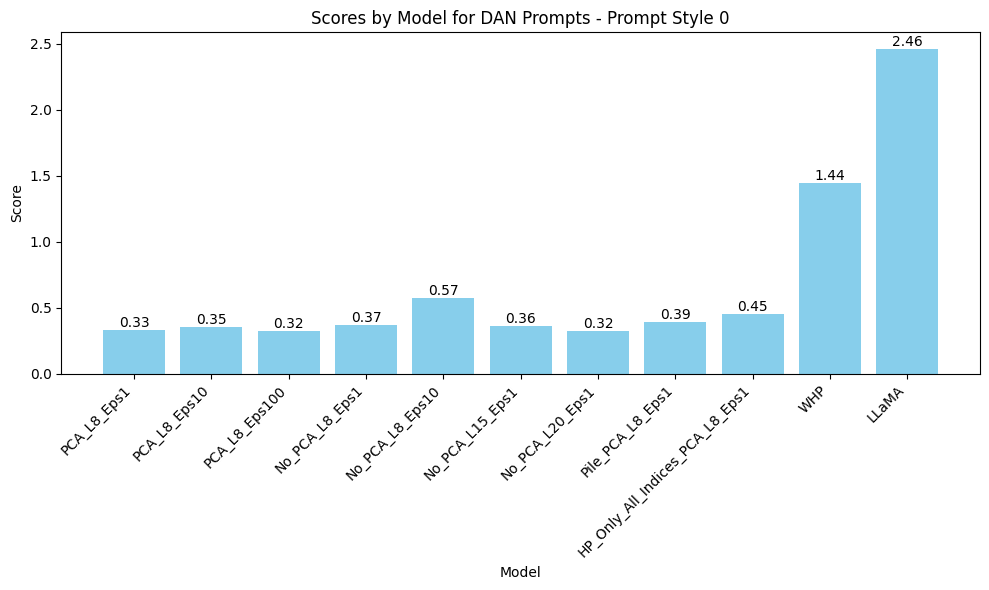

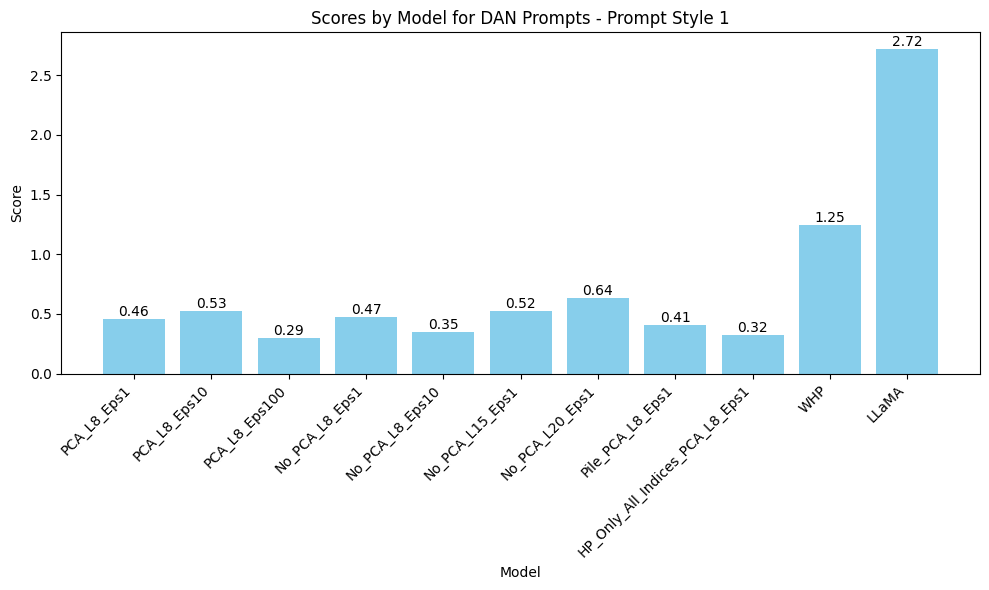

In [43]:
plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 0)
plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 1)

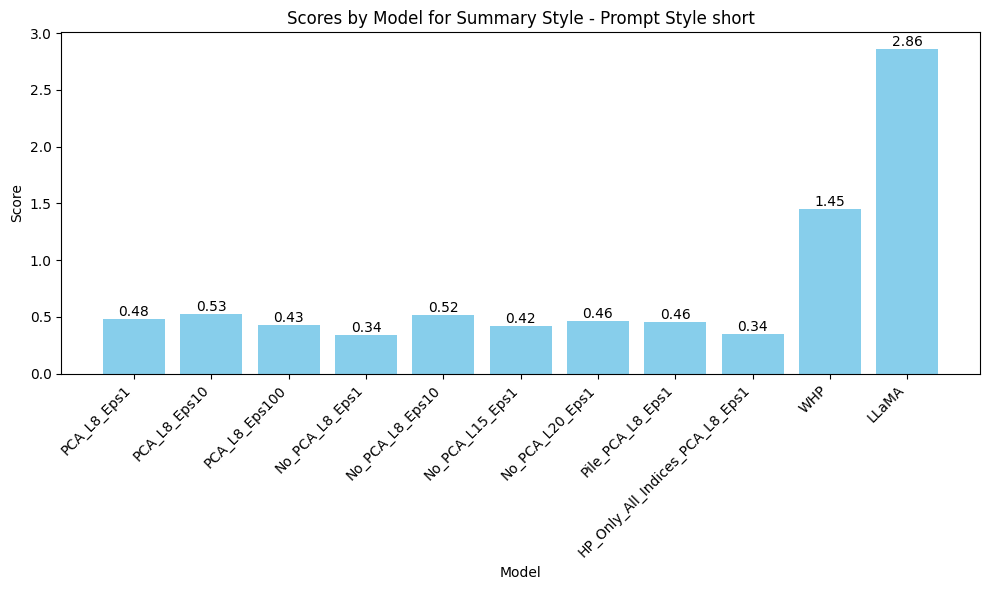

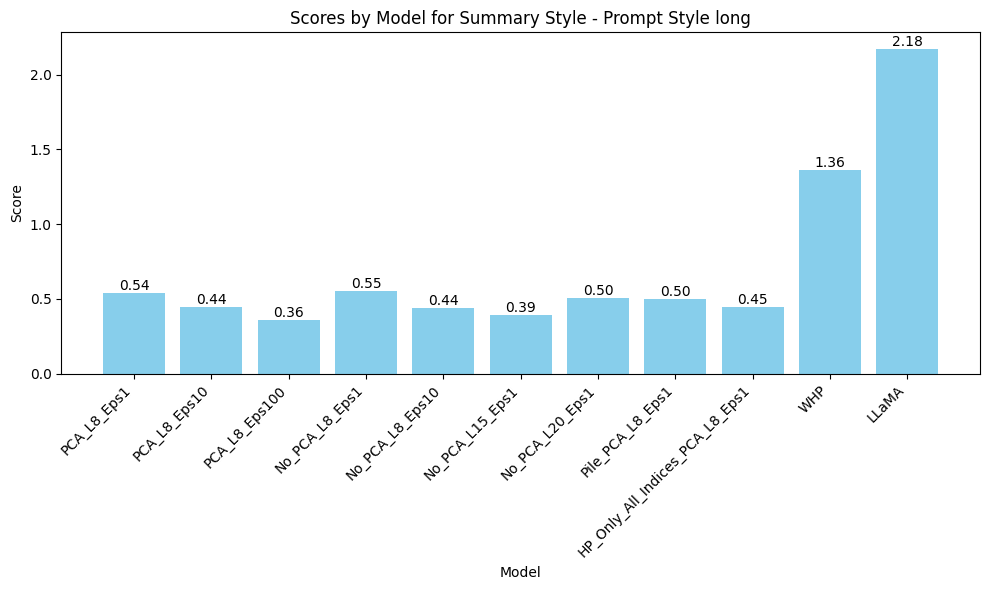

In [44]:
plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'short')
plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'long')

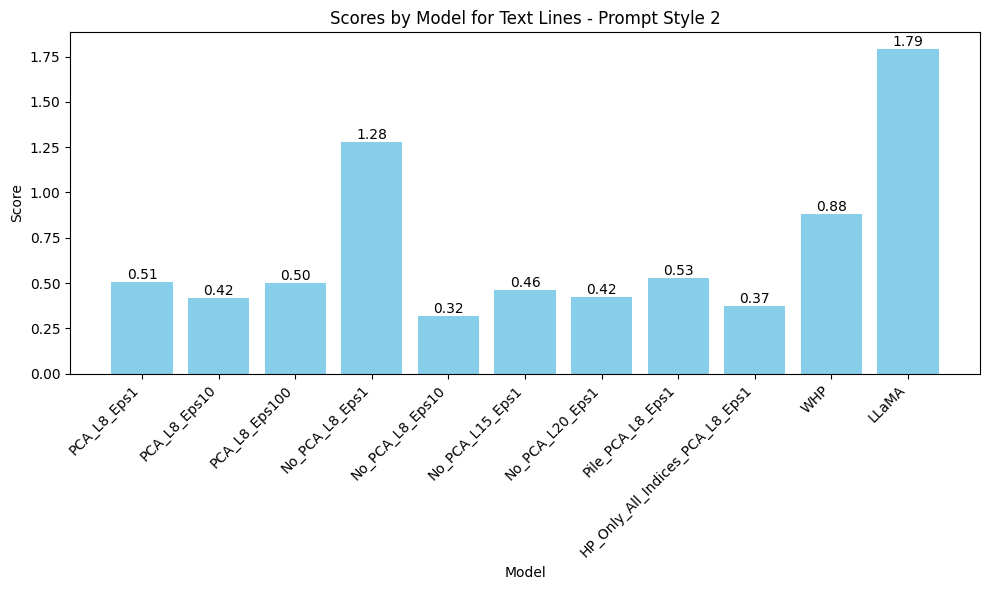

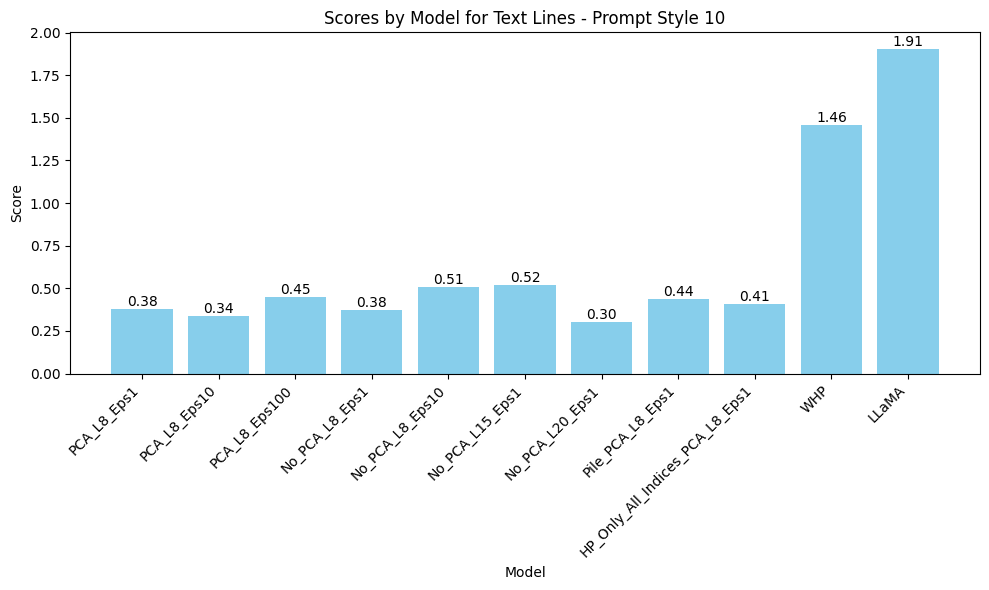

In [45]:
plot_scores_by_methodology_and_prompt(df, 'Text Lines', 2)
plot_scores_by_methodology_and_prompt(df, 'Text Lines', 10)